# ¿Por qué un ajolote regenera su pata y tú no?

Tu dedo no vuelve a crecer si lo pierdes. El de una rana, sí. ¿La diferencia? Podría ser algo tan simple como la forma en que tus células detectan el oxígeno.

---
**Paper:** Tsissios *et al.* (2026) — *Species-specific oxygen sensing governs the initiation of vertebrate limb regeneration*
**Journal:** Science · **DOI:** [10.1126/science.adw8526](https://doi.org/10.1126/science.adw8526)
**Datos:** [GitHub — BICC-UNIL-EPFL](https://github.com/BICC-UNIL-EPFL/multiSpecies_limbRegeneration) (scRNA-seq + multiomics)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-04-12-oxigeno-regeneracion-extremidades-vertebrados/notebook.ipynb)

## El rompecabezas de la regeneración

Los anfibios como el ajolote (*Ambystoma mexicanum*) y las ranas (*Xenopus laevis*) pueden regenerar extremidades completas después de una amputación. Los mamíferos no. ¿Por qué?

¿Cómo lo probaron? Secuenciaron más de 21.000 células individuales de 5 especies — ratón, humano, pollo, *Xenopus* y ajolote — y compararon quién tiene encendidos los genes de detección de oxígeno.

La hipótesis: las especies que regeneran **casi no detectan el oxígeno** — y eso deja activo un factor de transcripción (HIF1A) que enciende los programas de regeneración.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Tsissios et al. (2026), Science | Datos: GitHub BICC-UNIL-EPFL'
COLOR_NO_REGEN = '#DC2626'     # Rojo — no regenerativas
COLOR_REGEN = '#2563EB'        # Azul CaM — regenerativas
COLOR_GLUCOLISIS = '#D97706'   # Amber — glucólisis
COLOR_OXPHOS = '#059669'       # Emerald — fosforilación oxidativa
COLOR_CONTROL = '#BBBBBB'      # Gris — control
COLOR_TRATAMIENTO = '#7C3AED'  # Violeta — tratamiento AER

# ══════════════════════════════════════════════════════════════
# Setup + carga
# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
sensores = pd.read_csv('datos/sensores_por_especie.csv')
sensores_raw = pd.read_csv('datos/sensores_oxigeno_especies.csv')
metabolismo = pd.read_csv('datos/metabolismo_por_celula.csv')
composicion = pd.read_csv('datos/composicion_celular_tratamiento.csv')

print('Datos cargados:')
print(f'  Sensores de oxígeno: {len(sensores_raw)} mediciones, '
      f'{sensores_raw["gen"].nunique()} genes × {sensores_raw["especie"].nunique()} especies')
print(f'  Metabolismo celular: {len(metabolismo):,} células (Ratón + Xenopus)')
print(f'  Composición celular: {len(composicion)} tipos celulares × 3 condiciones')
print(f'\nEspecies regenerativas: Xenopus, Ajolote')
print(f'Especies no regenerativas: Ratón, Humano, Pollo')

Datos cargados:
  Sensores de oxígeno: 68 mediciones, 6 genes × 5 especies
  Metabolismo celular: 21,701 células (Ratón + Xenopus)
  Composición celular: 18 tipos celulares × 3 condiciones

Especies regenerativas: Xenopus, Ajolote
Especies no regenerativas: Ratón, Humano, Pollo


## Los sensores de oxígeno

Tres proteínas controlan el destino de HIF1A — el factor de transcripción que activa los programas regenerativos:

- **EGLN1** (PHD2): el sensor de oxígeno principal. Cuando hay oxígeno, marca a HIF1A para destrucción
- **VHL**: el verdugo. Recibe a HIF1A marcado y lo destruye
- **HIF1AN** (FIH): un inhibidor adicional que desactiva a HIF1A

Si estas tres proteínas están activas, HIF1A no dura. Si están silenciadas... regeneración.

Veamos quién las tiene encendidas.

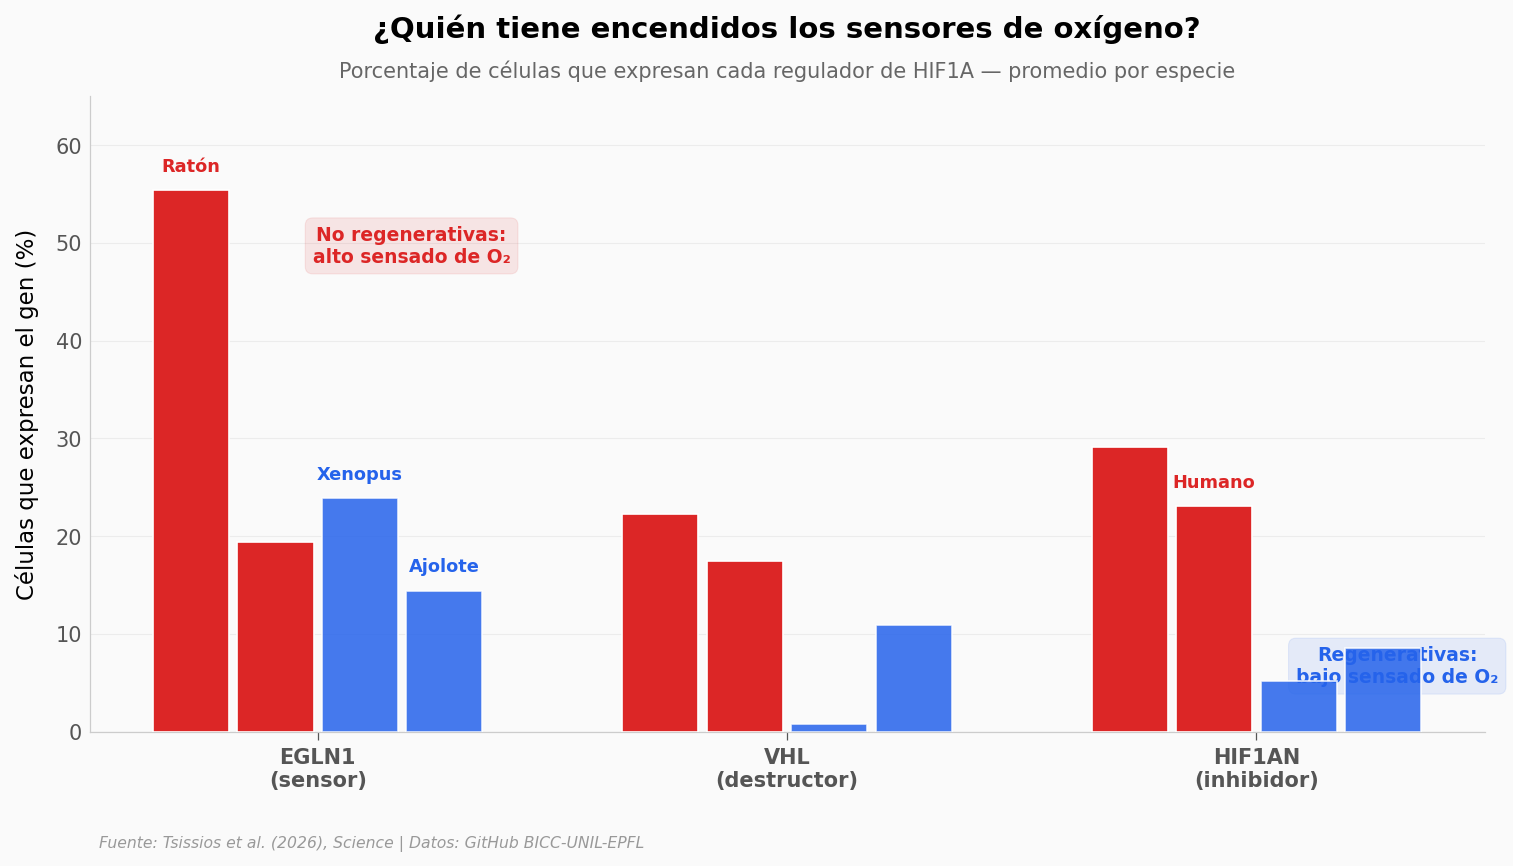

In [2]:
# ── Gráfica hero: sensores de oxígeno por especie ──
genes_hero = ['EGLN1', 'VHL', 'HIF1AN']
gene_labels = {'EGLN1': 'EGLN1\n(sensor)', 'VHL': 'VHL\n(destructor)', 'HIF1AN': 'HIF1AN\n(inhibidor)'}
especies_orden = ['Ratón', 'Humano', 'Xenopus', 'Ajolote']

fig, ax = plt.subplots(figsize=(12, 5.5))

bar_width = 0.18
x_base = np.arange(len(genes_hero))

for i, sp in enumerate(especies_orden):
    sub = sensores[(sensores['gen'].isin(genes_hero)) & (sensores['especie_es'] == sp)]
    sub = sub.set_index('gen').reindex(genes_hero)
    regen = sub['regenerativa_es'].iloc[0] if len(sub) > 0 else 'No'
    color = COLOR_REGEN if regen == 'Sí' else COLOR_NO_REGEN
    alpha = 1.0 if regen == 'No' else 0.85
    edge = 'white'
    
    x_pos = x_base + (i - 1.5) * bar_width
    vals = sub['pct_media'].values
    
    bars = ax.bar(x_pos, vals, bar_width * 0.9, color=color, alpha=alpha,
                  edgecolor=edge, linewidth=0.8, zorder=5)
    
    # Inline label on the tallest bar of each species
    max_idx = np.argmax(vals)
    label_y = vals[max_idx] + 1.5
    ax.text(x_pos[max_idx], label_y, sp, fontsize=8.5, fontweight='bold',
            color=color, ha='center', va='bottom')

# Gene labels
ax.set_xticks(x_base)
ax.set_xticklabels([gene_labels[g] for g in genes_hero], fontsize=10, fontweight='bold')

ax.set_ylabel('Células que expresan el gen (%)', fontsize=11)
ax.set_title('¿Quién tiene encendidos los sensores de oxígeno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje de células que expresan cada regulador de HIF1A — promedio por especie',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Reference lines
ax.axhline(y=0, color='#CCCCCC', linewidth=0.5, zorder=1)

# Annotation: the key insight
ax.annotate('Regenerativas:\nbajo sensado de O₂',
            xy=(2.3, 5), fontsize=9, color=COLOR_REGEN,
            fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=COLOR_REGEN, alpha=0.1, edgecolor=COLOR_REGEN))

ax.annotate('No regenerativas:\nalto sensado de O₂',
            xy=(0.2, 48), fontsize=9, color=COLOR_NO_REGEN,
            fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=COLOR_NO_REGEN, alpha=0.1, edgecolor=COLOR_NO_REGEN))

ax.set_ylim(0, 65)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sensores_oxigeno_especies.png', dpi=200, bbox_inches='tight')
plt.show()

### ¿Qué vemos?

El patrón es consistente en los tres reguladores:

- **EGLN1**, el sensor principal: en el ratón lo expresan el 55% de las células (n = 4 estadios). En *Xenopus*, solo el 24% �� 2,3 veces menos (d = 2,90, p = 0,029, n = 4). En el ajolote, apenas el 14% (n = 3)
- **VHL**, el destructor de HIF1A: el ratón lo tiene en el 22% de sus células (n = 4 estadios). *Xenopus*, en menos del 1% (d = 6,57, n = 3). Es decir, la rana prácticamente **no tiene la maquinaria para destruir HIF1A**
- **HIF1AN**: 29% en ratón (n = 4 estadios) vs 5% en *Xenopus* (n = 1 estadio) — 5,7 veces menos. ⚠️ Dato de Xenopus basado en un solo estadio

Lo interesante: HIF1A en sí se expresa de forma similar en ambas especies (~63% ratón, ~59% *Xenopus*). Ambos lo fabrican. La diferencia es que el ratón lo destruye apenas lo produce, y la rana lo deja actuar.

## El interruptor metabólico

Si HIF1A sobrevive, cambia el metabolismo de la célula: la empuja hacia la glucólisis (fermentación sin oxígeno) y lejos de la fosforilación oxidativa (respiración aeróbica). Los scores AUCell miden actividad metabólica en cada célula individual — 5.169 de ratón y 16.532 de *Xenopus*, en dos condiciones de cultivo.

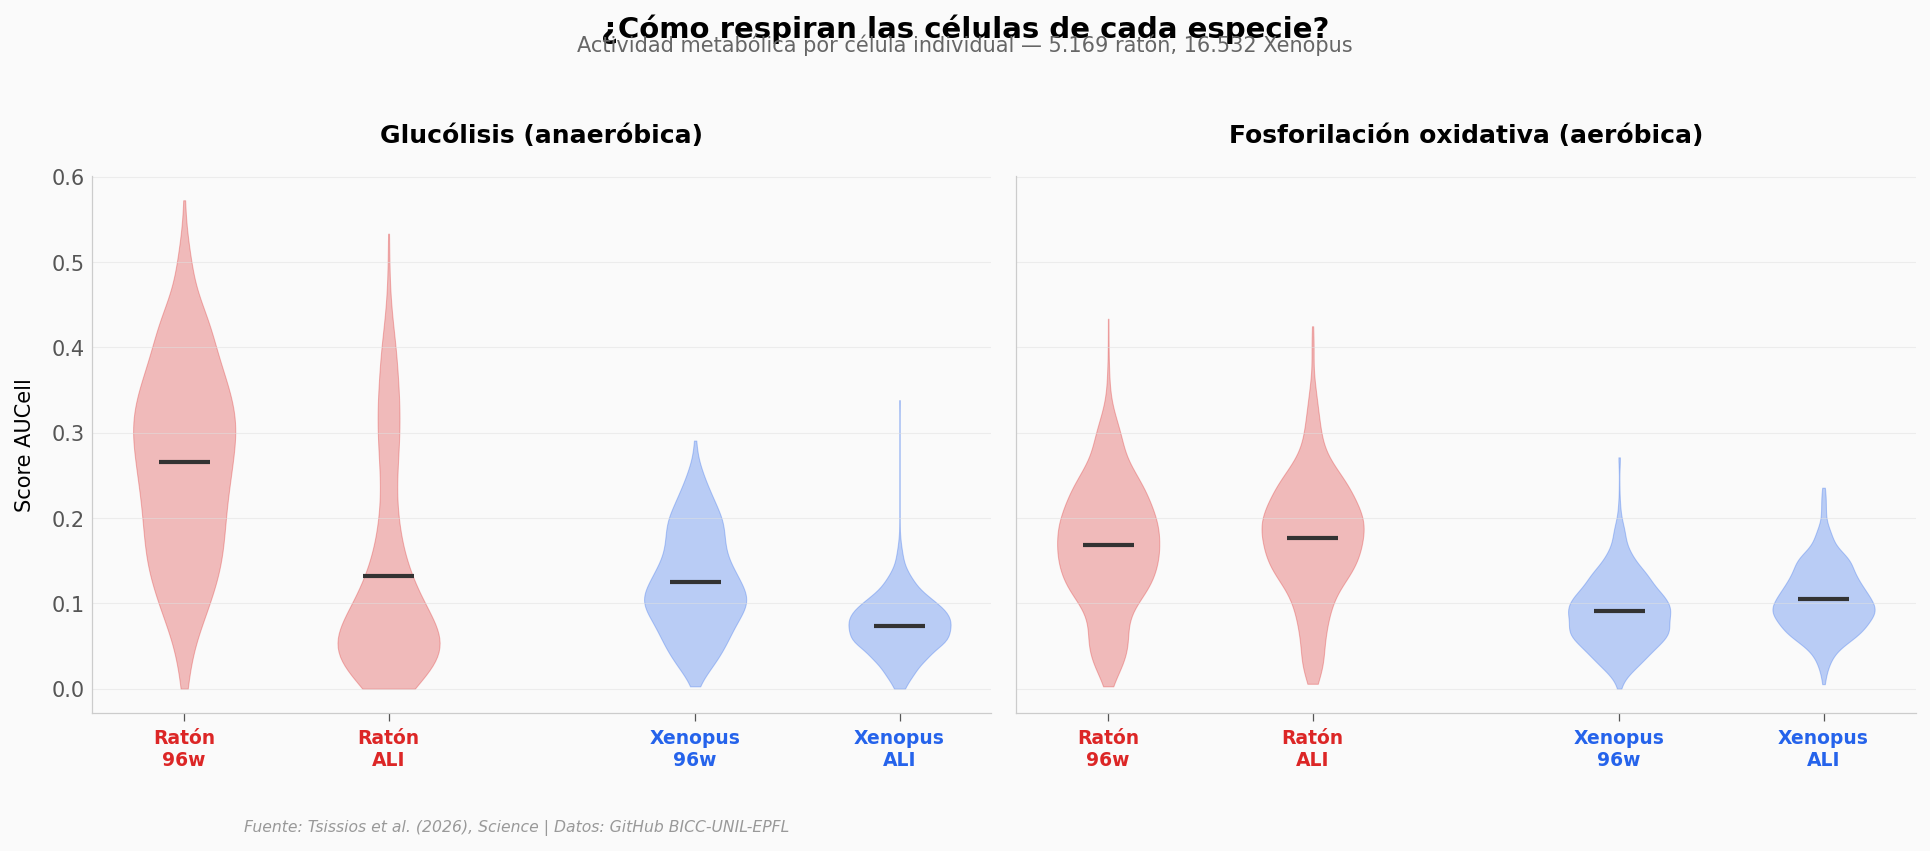

In [3]:
# ── Metabolismo: glucólisis vs fosforilación oxidativa ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# Subsample for visualization (keep distributions representative)
np.random.seed(42)
samples = []
for sp in metabolismo['especie'].unique():
    for cond in metabolismo['condicion'].unique():
        sub = metabolismo[(metabolismo['especie']==sp) & (metabolismo['condicion']==cond)]
        if len(sub) > 800:
            sub = sub.sample(800, random_state=42)
        samples.append(sub)
met_sample = pd.concat(samples, ignore_index=True)

for ax_idx, (pathway, label, color) in enumerate([
    ('glucolisis', 'Glucólisis (anaeróbica)', COLOR_GLUCOLISIS),
    ('oxphos', 'Fosforilación oxidativa (aeróbica)', COLOR_OXPHOS)
]):
    ax = axes[ax_idx]
    groups = [
        ('Ratón\n96w', met_sample[(met_sample['especie']=='Ratón') & (met_sample['condicion']=='96w')][pathway]),
        ('Ratón\nALI', met_sample[(met_sample['especie']=='Ratón') & (met_sample['condicion']=='ALI')][pathway]),
        ('Xenopus\n96w', met_sample[(met_sample['especie']=='Xenopus') & (met_sample['condicion']=='96w')][pathway]),
        ('Xenopus\nALI', met_sample[(met_sample['especie']=='Xenopus') & (met_sample['condicion']=='ALI')][pathway]),
    ]
    positions = [0, 1, 2.5, 3.5]
    colors_v = [COLOR_NO_REGEN, COLOR_NO_REGEN, COLOR_REGEN, COLOR_REGEN]
    
    parts = ax.violinplot([g[1].values for g in groups], positions=positions,
                          showmeans=True, showmedians=False, showextrema=False)
    
    for pc, c in zip(parts['bodies'], colors_v):
        pc.set_facecolor(c)
        pc.set_alpha(0.3)
        pc.set_edgecolor(c)
    parts['cmeans'].set_color('#333333')
    parts['cmeans'].set_linewidth(2)
    
    ax.set_xticks(positions)
    ax.set_xticklabels([g[0] for g in groups], fontsize=9, fontweight='bold')
    for tick, c in zip(ax.get_xticklabels(), colors_v):
        tick.set_color(c)
    
    ax.set_title(label, fontsize=12, fontweight='bold', pad=16)
    ax.set_ylabel('Score AUCell' if ax_idx == 0 else '', fontsize=10)

fig.suptitle('¿Cómo respiran las células de cada especie?',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 0.99, 'Actividad metabólica por célula individual — 5.169 ratón, 16.532 Xenopus',
         fontsize=10, color='#666666', ha='center', transform=fig.transFigure)

fig.text(0.13, -0.05, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/metabolismo_especies.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que muestran los violines

El ratón tiene niveles de glucólisis mucho más variables entre condiciones de cultivo — la condición 96w (pozo convencional) muestra glucólisis alta, mientras que en ALI (interfaz aire-líquido, más oxígeno) baja drásticamente (d de Cohen = 1,15, Mann-Whitney p < 10⁻²⁸⁹, n = 3.006 vs 2.163 células).

En *Xenopus*, la glucólisis parte de niveles más bajos y también baja con ALI (d = 1,10), pero la diferencia absoluta es menor que en ratón (0,055 vs 0,132). Sus células reaccionan al oxígeno, pero desde un punto de partida más bajo — como si su termostato metabólico estuviera calibrado a un nivel inferior.

## ¿Se puede empujar al ratón hacia la regeneración?

El equipo probó algo audaz: trataron extremidades embrionarias de ratón con **factores AER** — señales de crecimiento de la cresta ectodérmica apical, la estructura que dirige el crecimiento de las extremidades. ¿Cambió la composición celular?

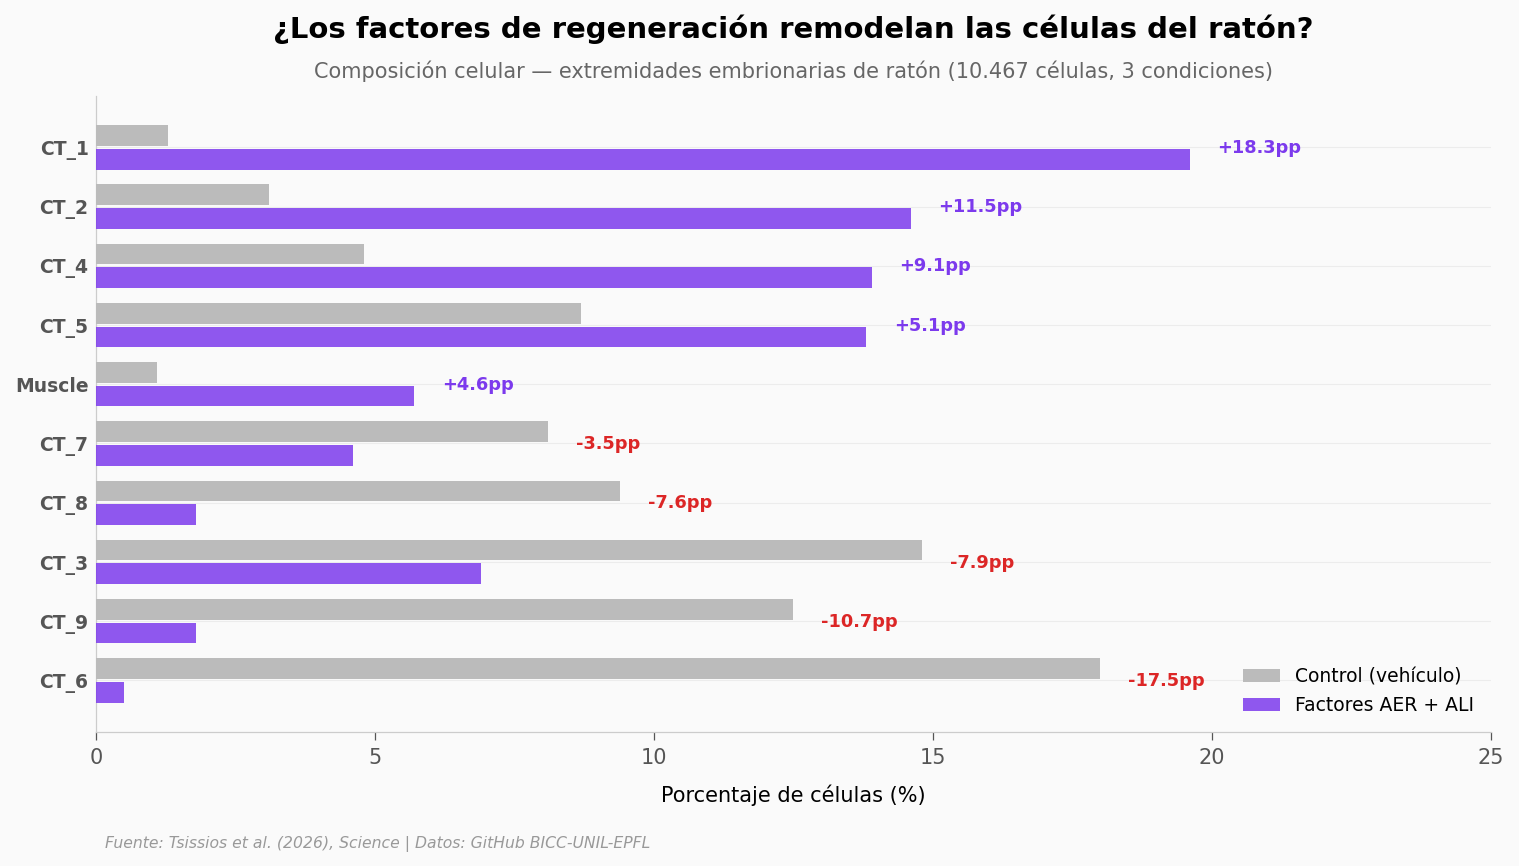

Tipos celulares que se expanden con AER: 5
Tipos celulares que se contraen: 5
Mayor expansión: CT_1 (+18.3pp)
Mayor contracción: CT_6 (-17.5pp)


In [4]:
# ── Composición celular: control vs tratamiento AER ──
comp = composicion.copy()

# Top changes (|delta| > 3pp)
comp['delta'] = comp['Mouse_AERfactorsALI_pc'] - comp['Mouse_VehCtrl96w_pc']
comp_sig = comp[abs(comp['delta']) > 3].sort_values('delta', ascending=True)

fig, ax = plt.subplots(figsize=(12, 5.5))

y_pos = np.arange(len(comp_sig))
bars_ctrl = ax.barh(y_pos + 0.2, comp_sig['Mouse_VehCtrl96w_pc'], 0.35,
                    color=COLOR_CONTROL, label='Control (vehículo)', zorder=5)
bars_aer = ax.barh(y_pos - 0.2, comp_sig['Mouse_AERfactorsALI_pc'], 0.35,
                   color=COLOR_TRATAMIENTO, alpha=0.85, label='Factores AER + ALI', zorder=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(comp_sig['cellType'].values, fontsize=9, fontweight='bold')
ax.set_xlabel('Porcentaje de células (%)', fontsize=10)

# Annotate big changes
for i, (_, row) in enumerate(comp_sig.iterrows()):
    delta = row['delta']
    x_pos = max(row['Mouse_VehCtrl96w_pc'], row['Mouse_AERfactorsALI_pc']) + 0.5
    sign = '+' if delta > 0 else ''
    color = COLOR_TRATAMIENTO if delta > 0 else COLOR_NO_REGEN
    ax.text(x_pos, i, f'{sign}{delta:.1f}pp', fontsize=8.5, fontweight='bold',
            color=color, va='center')

ax.set_title('¿Los factores de regeneración remodelan las células del ratón?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Composición celular — extremidades embrionarias de ratón (10.467 células, 3 condiciones)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='lower right', framealpha=0.9)
ax.set_xlim(0, 25)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/composicion_tratamiento.png', dpi=200, bbox_inches='tight')
plt.show()

# Print summary
expanding = comp_sig[comp_sig['delta'] > 0]
shrinking = comp_sig[comp_sig['delta'] < 0]
print(f'Tipos celulares que se expanden con AER: {len(expanding)}')
print(f'Tipos celulares que se contraen: {len(shrinking)}')
print(f'Mayor expansión: {expanding.iloc[-1]["cellType"]} (+{expanding.iloc[-1]["delta"]:.1f}pp)')
print(f'Mayor contracción: {shrinking.iloc[0]["cellType"]} ({shrinking.iloc[0]["delta"]:.1f}pp)')

### El remodelado es dramático

Los factores AER transforman la composición celular de la extremidad del ratón:

- **CT_1** salta del 1,3% al 19,6% — una expansión de +18,3 puntos porcentuales
- **CT_6** colapsa del 18,0% al 0,5% — prácticamente desaparece
- **CT_9** baja del 12,5% al 1,8%

Los factores de crecimiento están literalmente remodelando la composición de la extremidad — amplificando algunos tipos celulares y suprimiendo otros. Este remodelado, combinado con la reducción de oxígeno, es la combinación que — según los datos — podría desbloquear la regeneración en mamíferos.

## ¿Qué tan lejos estamos?

Veamos la distribución completa de EGLN1 — el sensor de oxígeno principal — en todos los estadios y especies.

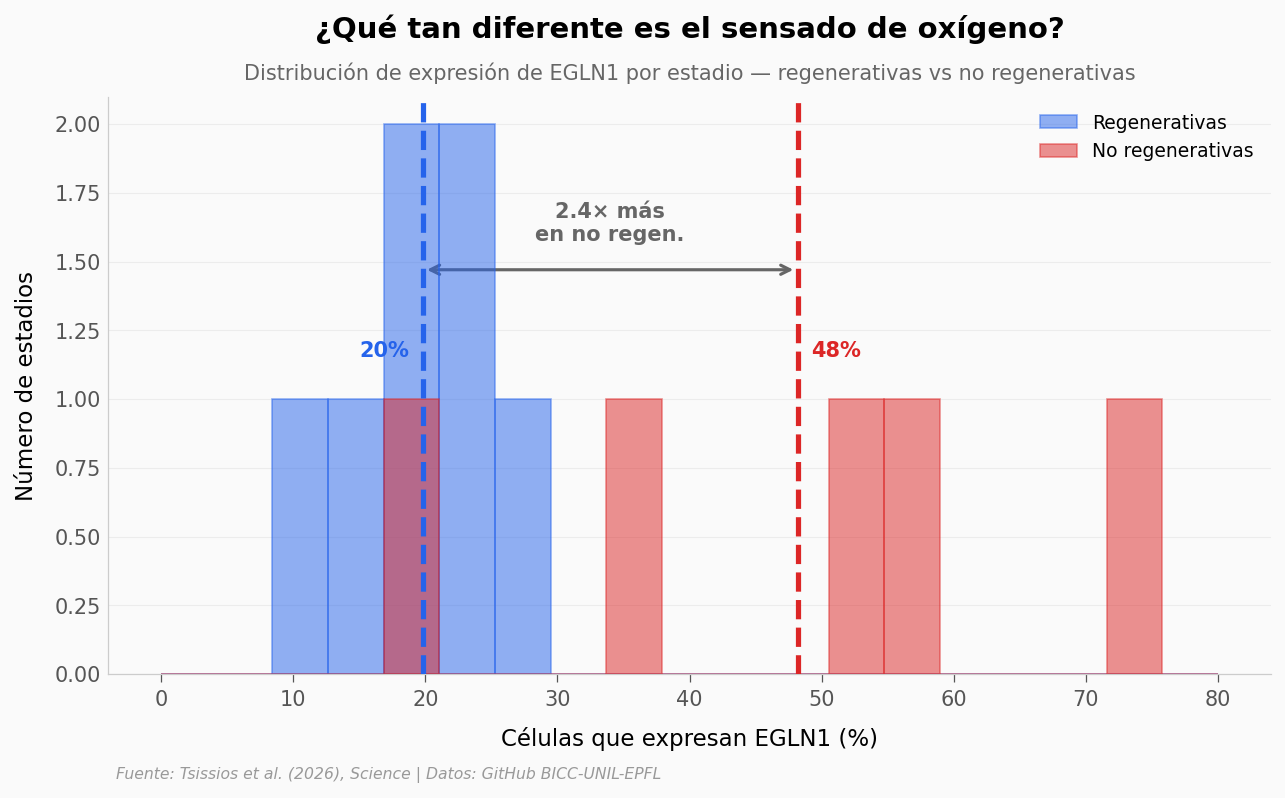

EGLN1 — regenerativas: media=19.8%, n=7 estadios
EGLN1 — no regenerativas: media=48.2%, n=5 estadios
Ratio: 2.4×


In [5]:
# ── Histograma de anomalía: EGLN1 por estadio y especie ──
egln1 = sensores_raw[sensores_raw['gen'] == 'EGLN1'].copy()

fig, ax = plt.subplots(figsize=(10, 5))

regen_vals = egln1[egln1['regenerativa_es'] == 'Sí']['pct_celulas'].values
no_regen_vals = egln1[egln1['regenerativa_es'] == 'No']['pct_celulas'].values

bins = np.linspace(0, 80, 20)

ax.hist(regen_vals, bins=bins, color=COLOR_REGEN, alpha=0.5,
        edgecolor=COLOR_REGEN, linewidth=0.8, label='Regenerativas', zorder=5)
ax.hist(no_regen_vals, bins=bins, color=COLOR_NO_REGEN, alpha=0.5,
        edgecolor=COLOR_NO_REGEN, linewidth=0.8, label='No regenerativas', zorder=5)

# Means
mean_regen = regen_vals.mean()
mean_no_regen = no_regen_vals.mean()

ax.axvline(x=mean_regen, color=COLOR_REGEN, linewidth=2.5, linestyle='--', zorder=6)
ax.axvline(x=mean_no_regen, color=COLOR_NO_REGEN, linewidth=2.5, linestyle='--', zorder=6)

y_max = ax.get_ylim()[1]
ax.annotate('', xy=(mean_no_regen, y_max * 0.7), xytext=(mean_regen, y_max * 0.7),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((mean_regen + mean_no_regen) / 2, y_max * 0.75,
        f'{mean_no_regen/mean_regen:.1f}× más\nen no regen.',
        fontsize=10, fontweight='bold', color='#666666', ha='center')

ax.text(mean_regen - 1, y_max * 0.55, f'{mean_regen:.0f}%',
        fontsize=10, fontweight='bold', color=COLOR_REGEN, ha='right')
ax.text(mean_no_regen + 1, y_max * 0.55, f'{mean_no_regen:.0f}%',
        fontsize=10, fontweight='bold', color=COLOR_NO_REGEN, ha='left')

ax.set_xlabel('Células que expresan EGLN1 (%)', fontsize=11)
ax.set_ylabel('Número de estadios', fontsize=11)
ax.set_title('¿Qué tan diferente es el sensado de oxígeno?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Distribución de expresión de EGLN1 por estadio — regenerativas vs no regenerativas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

ax.legend(fontsize=9, loc='upper right', framealpha=0.9)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_egln1.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'EGLN1 — regenerativas: media={mean_regen:.1f}%, n={len(regen_vals)} estadios')
print(f'EGLN1 — no regenerativas: media={mean_no_regen:.1f}%, n={len(no_regen_vals)} estadios')
print(f'Ratio: {mean_no_regen/mean_regen:.1f}×')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Las especies regenerativas expresan menos sensores de oxígeno (EGLN1, VHL, HIF1AN) | ✅ | EGLN1: 2,3× menos (d = 2,90, n = 4 vs 4). VHL: 29× menos (d = 6,57, n = 4 vs 3). HIF1AN: 5,7× menos (n = 4 vs 1 ⚠️). Patrón consistente en los 3 reguladores |
| HIF1A se expresa en ambos tipos de especies | ✅ | Ratón: 62,6%. *Xenopus*: 58,8%. La diferencia está en la degradación, no en la producción |
| Bajar el oxígeno induce curación rápida en ratón | ✅ (claim experimental del paper) | El abstract usa "induced" — manipulación directa. No verificable con estos datos (scRNA-seq, no ensayo funcional) |
| Los factores AER remodelan la composición celular del ratón | ✅ | CT_1: +18,3pp. CT_6: −17,5pp. Cambios dramáticos en múltiples tipos celulares |
| El sensado de oxígeno es un mecanismo "targetable" para desbloquear regeneración | ⚠️ | El paper lo enmarca como potencial futuro ("can unlock"). Los datos muestran la correlación entre baja expresión de sensores y capacidad regenerativa, pero el salto a terapia en mamíferos adultos no está demostrado |

> **Limitaciones:** (1) Los datos de expresión comparan embriones, no adultos — la relevancia para regeneración adulta requiere validación adicional. (2) Los tipos celulares (CT_1 a CT_15) son clústeres computacionales sin identidad biológica definida en estos datos. (3) La comparación cruzada entre especies usa ortólogos que pueden tener regulación diferencial no capturada por scRNA-seq. (4) n = 1 para humano y pollo (un solo estadio embrionario cada uno).

## Ahora tú

1. **¿Qué pasa con EGLN2 y EGLN3?** Nosotros nos enfocamos en EGLN1, VHL y HIF1AN, pero hay otros reguladores en los datos. ¿Siguen el mismo patrón entre especies? Pista: filtra `sensores_raw[sensores_raw['gen'] == 'EGLN2']`

2. **¿El ajolote se parece más a la rana o al ratón?** En la gráfica hero, el ajolote está entre ambos mundos para algunos genes. ¿En cuáles se parece más a *Xenopus* y en cuáles al ratón?

3. **¿Hay tipos celulares del ratón que resistan el tratamiento AER?** La composición muestra que algunos tipos ni se expanden ni se contraen. ¿Cuáles son y qué podría significar?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué tan diferente es el ajolote del ratón para CADA gen?
genes_todos = ['HIF1A', 'EGLN1', 'EGLN2', 'EGLN3', 'VHL', 'HIF1AN']
sp_compare = ['Ratón', 'Ajolote', 'Xenopus']

result = sensores[sensores['gen'].isin(genes_todos) & sensores['especie_es'].isin(sp_compare)]
pivot = result.pivot_table(index='gen', columns='especie_es', values='pct_media')
pivot = pivot.reindex(genes_todos)
pivot = pivot[sp_compare]

print('Porcentaje de células que expresan cada gen:')
print(pivot.round(1).to_string())
print()

# Ratio vs ratón
for sp in ['Ajolote', 'Xenopus']:
    ratio = pivot['Ratón'] / pivot[sp]
    print(f'\nRatio Ratón/{sp}:')
    for gene in genes_todos:
        if not np.isnan(ratio.get(gene, np.nan)):
            r = ratio[gene]
            print(f'  {gene:8}: {r:.1f}× {"(ratón >> {})".format(sp.lower()) if r > 2 else "(similar)" if r < 1.5 else "(ratón > {})".format(sp.lower())}')

Porcentaje de células que expresan cada gen:
especie_es  Ratón  Ajolote  Xenopus
gen                                
HIF1A        62.6     40.7     58.8
EGLN1        55.4     14.4     23.8
EGLN2        64.2      NaN     12.1
EGLN3         3.7      3.0      3.6
VHL          22.2     10.9      0.8
HIF1AN       29.1      8.6      5.1


Ratio Ratón/Ajolote:
  HIF1A   : 1.5× (ratón > ajolote)
  EGLN1   : 3.8× (ratón >> ajolote)
  EGLN3   : 1.2× (similar)
  VHL     : 2.0× (ratón >> ajolote)
  HIF1AN  : 3.4× (ratón >> ajolote)

Ratio Ratón/Xenopus:
  HIF1A   : 1.1× (similar)
  EGLN1   : 2.3× (ratón >> xenopus)
  EGLN2   : 5.3× (ratón >> xenopus)
  EGLN3   : 1.0× (similar)
  VHL     : 29.5× (ratón >> xenopus)
  HIF1AN  : 5.7× (ratón >> xenopus)


---
## Créditos

- **Paper:** Tsissios, G. *et al.* (2026). Species-specific oxygen sensing governs the initiation of vertebrate limb regeneration. *Science*. DOI: [10.1126/science.adw8526](https://doi.org/10.1126/science.adw8526)
- **Datos:** [GitHub — BICC-UNIL-EPFL/multiSpecies_limbRegeneration](https://github.com/BICC-UNIL-EPFL/multiSpecies_limbRegeneration) (CC-BY, scRNA-seq + ATAC-seq processed data)
- **Código:** [Zenodo 10.5281/zenodo.18234470](https://zenodo.org/records/18234470)
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)

*Notebook generado por Claude para [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)*